# 03-text-analysis: phân tích và làm rõ dữ liệu text

## 1. import libraries

In [4]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

import nltk
nltk.download("punkt")
nltk.download("stopwords")

from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


## 2. Load dataset

In [5]:
data_dir = "../../data/iu_xray"

annotation_path = os.path.join(data_dir, "annotation.json")

with open(annotation_path, "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['train', 'val', 'test'])


## 3. Convert annotation (json) -> DataFrame

In [6]:
records = []

for split in ["train","val","test"]:

    for item in data[split]:

        records.append({
            "id": item["id"],
            "report": item["report"],
            "split": split
        })

df = pd.DataFrame(records)

print("Total reports:", len(df))
df.head()

Total reports: 2955


,id,report,split
0,CXR2384_IM-0942,The heart size and pulmonary vascularity appea...,train
1,CXR2926_IM-1328,Cardiac and mediastinal contours are within no...,train
2,CXR1451_IM-0291,Left lower lobe calcified granuloma. Heart siz...,train
3,CXR2887_IM-1289,The cardiomediastinal silhouette is normal in ...,train
4,CXR1647_IM-0424,"The lungs are clear bilaterally. Specifically,...",train


## 4. Report lenght distribute

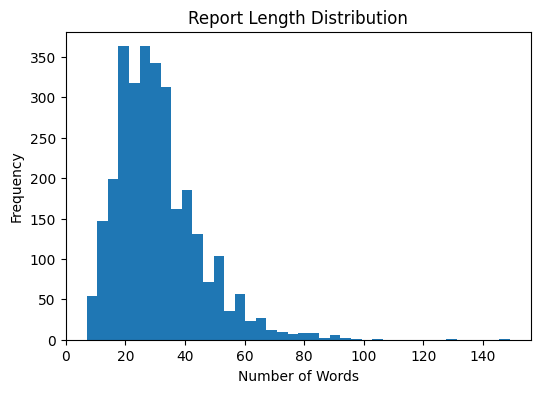

Min: 7
Max: 149
Mean: 31.000338409475464


In [7]:
df["report_length"] = df["report"].apply(lambda x: len(x.split()))

plt.figure(figsize=(6,4))
plt.hist(df["report_length"], bins=40)
plt.title("Report Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print("Min:", df["report_length"].min())
print("Max:", df["report_length"].max())
print("Mean:", df["report_length"].mean())

Cột x là số từ trong khoảng 7-> 149 từ

Cột y là tần xuất suất hiện của các câu có số từ x liên quan

**Nhận xét:**
* Độ dài báo cáo phân bố lệch phải (right-skewed).
* Phần lớn report nằm khoảng 20–40 từ, tập trung nhiều nhất quanh ~30 từ.
* Mean ≈ 31 từ, phù hợp với vùng tập trung của histogram.
* Có một số ít report rất dài (tới 149 từ), tạo đuôi dài bên phải.
* Report ngắn nhất: 7 từ.

->Kết luận: đa số báo cáo X-ray khá ngắn và cô đọng, chỉ một số ít rất dài.

## 5. Sentence analysis

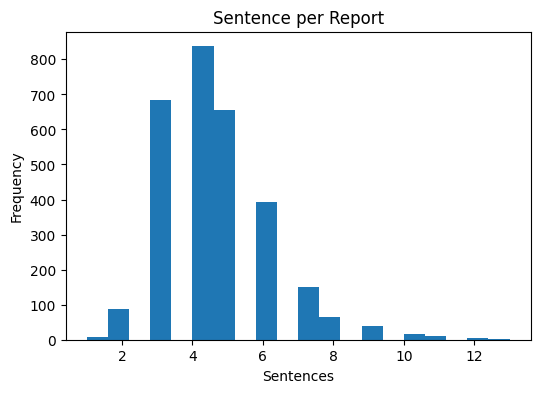

Average sentences: 4.577326565143824


In [8]:
df["num_sentences"] = df["report"].apply(lambda x: len(sent_tokenize(x)))

plt.figure(figsize=(6,4))
plt.hist(df["num_sentences"], bins=20)
plt.title("Sentence per Report")
plt.xlabel("Sentences")
plt.ylabel("Frequency")
plt.show()

print("Average sentences:", df["num_sentences"].mean())

* Trục X: số câu trong mỗi report (sentences per report).
* Trục Y: tần suất – số lượng report có số câu tương ứng.
* Mỗi cột biểu diễn bao nhiêu report có N câu.

**Nhận xét:**
* Phần lớn report có khoảng 3–6 câu.
* Trung bình ≈ 4.58 câu/report.
* Một số ít report dài hơn (8–13 câu) nhưng rất hiếm.
* Phân bố cũng lệch phải nhẹ (đa số report ngắn, ít report rất dài).

## 6. Lenght distribution

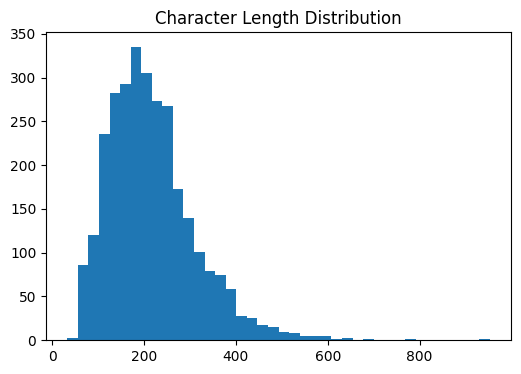

In [9]:
df["char_length"] = df["report"].apply(len)

plt.figure(figsize=(6,4))
plt.hist(df["char_length"], bins=40)
plt.title("Character Length Distribution")
plt.show()

* Trục X: số câu trong mỗi report (sentences per report).
* Trục Y: tần suất – số lượng report có số câu tương ứng.
* Mỗi cột biểu diễn bao nhiêu report có N câu.

**Nhận xét:**
* Phần lớn report có khoảng 3–6 câu.
* Trung bình ≈ 4.58 câu/report.
* Một số ít report dài hơn (8–13 câu) nhưng rất hiếm.
* Phân bố cũng lệch phải nhẹ (đa số report ngắn, ít report rất dài).

## 7. Vocabulary Analysis

In [10]:
words = []

for r in df["report"]:
    words.extend(r.lower().split())

vocab = set(words)

print("Vocabulary size:", len(vocab))
print("Total words:", len(words))

Vocabulary size: 2274
Total words: 91606


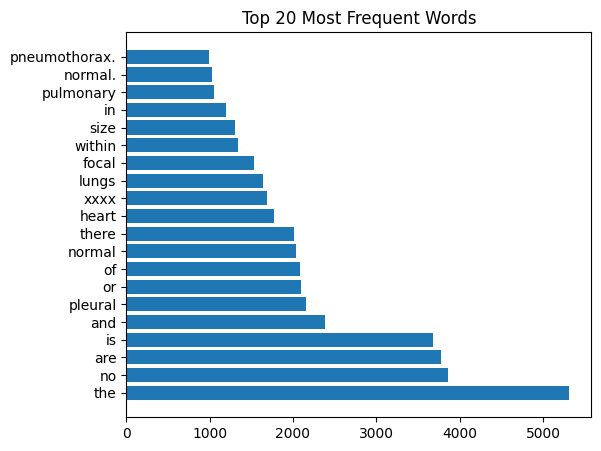

In [11]:
counter = Counter(words)

top_words = counter.most_common(20)

w = [x[0] for x in top_words]
c = [x[1] for x in top_words]

plt.figure(figsize=(6,5))
plt.barh(w,c)
plt.title("Top 20 Most Frequent Words")
plt.show()

Trục X: số lần xuất hiện của từ.

Trục Y: các từ xuất hiện nhiều nhất trong report.

Biểu đồ cho thấy Top 20 từ phổ biến nhất trong các báo cáo X-ray.

**Nhận xét:**
Các từ phổ biến nhất: the, no, are, is, and → các từ ngữ pháp (stopwords) xuất hiện rất nhiều.

Các từ mang ý nghĩa y khoa:

- pleural → liên quan đến màng phổi
- heart → tim
- lungs → phổi
- pulmonary → thuộc về phổi
- pneumothorax → tràn khí màng phổi

Từ “no” xuất hiện nhiều → điều này cho thấy đa số report mô tả không phát hiện bất thường

ví dụ:
- No pleural effusion
- No pneumothorax

Từ “normal” cũng xuất hiện nhiều
→ nhiều ảnh X-ray được kết luận bình thường.

Có token “xxxx”
→ thường là placeholder để ẩn thông tin bệnh nhân trong dataset.


## 8. Word frequency

In [12]:
stop_words = set(stopwords.words("english"))

filtered_words = [w for w in words if w not in stop_words]

counter_filtered = Counter(filtered_words)

counter_filtered.most_common(20)

[('pleural', 2162),
 ('normal', 2038),
 ('heart', 1777),
 ('xxxx', 1692),
 ('lungs', 1636),
 ('focal', 1529),
 ('within', 1342),
 ('size', 1299),
 ('pulmonary', 1049),
 ('normal.', 1027),
 ('pneumothorax.', 994),
 ('limits.', 945),
 ('effusion.', 875),
 ('pneumothorax', 759),
 ('mediastinal', 744),
 ('clear.', 743),
 ('right', 736),
 ('silhouette', 735),
 ('cardiomediastinal', 718),
 ('airspace', 699)]

## 9. Remove Stopword

In [13]:
diseases = [
"atelectasis",
"cardiomegaly",
"consolidation",
"edema",
"effusion",
"emphysema",
"fibrosis",
"hernia",
"infiltration",
"mass",
"nodule",
"pleural",
"pneumonia",
"pneumothorax"
]

for d in diseases:

    count = df["report"].str.contains(d, case=False).sum()

    print(f"{d}: {count}")

atelectasis: 191
cardiomegaly: 114
consolidation: 991
edema: 175
effusion: 2291
emphysema: 66
fibrosis: 10
hernia: 34
infiltration: 0
mass: 118
nodule: 179
pleural: 2120
pneumonia: 108
pneumothorax: 2098


## 10. Medical keyword frequency

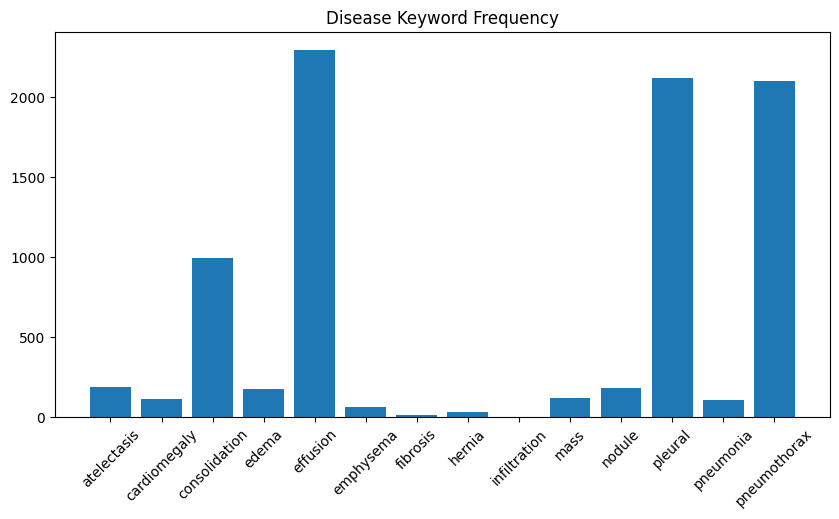

In [14]:
disease_counts = {}

for d in diseases:
    disease_counts[d] = df["report"].str.contains(d, case=False).sum()

plt.figure(figsize=(10,5))

plt.bar(disease_counts.keys(), disease_counts.values())

plt.xticks(rotation=45)

plt.title("Disease Keyword Frequency")

plt.show()

In [15]:
vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english"
)

X = vectorizer.fit_transform(df["report"])

sum_words = X.sum(axis=0)

bigrams = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

bigrams = sorted(bigrams, key=lambda x: x[1], reverse=True)

bigrams[:20]

[('pleural effusion', np.int64(1741)),
 ('normal limits', np.int64(1214)),
 ('heart size', np.int64(1080)),
 ('lungs clear', np.int64(1044)),
 ('effusion pneumothorax', np.int64(772)),
 ('cardiomediastinal silhouette', np.int64(607)),
 ('pneumothorax pleural', np.int64(600)),
 ('focal airspace', np.int64(542)),
 ('size normal', np.int64(492)),
 ('focal consolidation', np.int64(458)),
 ('silhouette normal', np.int64(428)),
 ('normal size', np.int64(418)),
 ('airspace disease', np.int64(377)),
 ('degenerative changes', np.int64(330)),
 ('mediastinal contours', np.int64(329)),
 ('pulmonary vascularity', np.int64(328)),
 ('large pleural', np.int64(300)),
 ('consolidation pneumothorax', np.int64(279)),
 ('thoracic spine', np.int64(274)),
 ('contours normal', np.int64(270))]

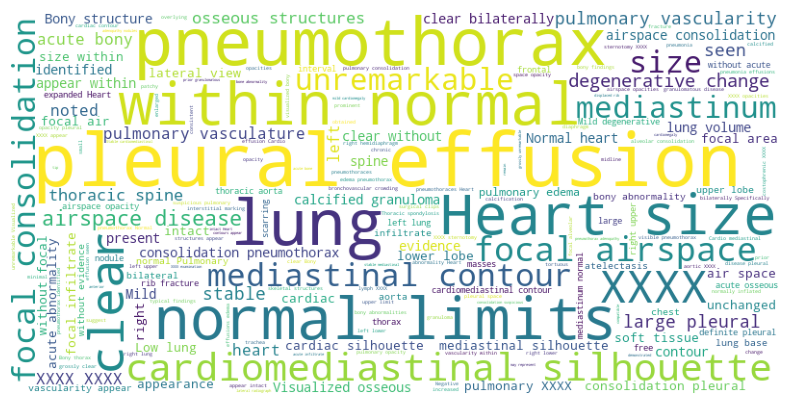

In [17]:
from wordcloud import WordCloud

text = " ".join(df["report"])

wc = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()